# Exploratory Data Analysis (EDA)

## Import Library

In [1]:
import pandas as pd
import numpy as np
import pandas_ta as ta
import matplotlib.pyplot as plt
from utils import load_analytics_dataset, show_3_distribution_charts, show_3_sns_charts
import warnings
warnings.filterwarnings('ignore')

## Load Feature Data

In [3]:
%%time
df = load_analytics_dataset()

CPU times: user 1min 48s, sys: 1.64 s, total: 1min 50s
Wall time: 2min 6s


### Show columns

In [4]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'hour', 'minute',
       'day_of_month', 'month', 'year',
       ...
       'short_mae', 'long_mfe', 'short_mfe', 'rr_long', 'rr_short',
       'eod_return_long', 'eod_return_short', 'price_range',
       'intraday_position', 'price_shape'],
      dtype='str', length=828)

### Thống kê cơ bản

In [5]:
df.describe()

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,remain_session_net_move,long_mae,short_mae,long_mfe,short_mfe,rr_long,rr_short,eod_return_long,eod_return_short,price_range
count,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,88026.000000,...,84440.000000,84440.000000,84440.000000,84440.000000,84440.000000,82812.000000,82905.000000,84440.000000,84440.000000,88026.000000
mean,1166.008474,1166.993196,1165.013523,1166.011180,3984.186434,11.184127,24.185127,15.939245,6.731204,2021.724400,...,-0.460364,0.573311,0.536818,0.536818,0.573311,4.990916,5.404580,-0.003962,0.003962,17.931752
std,269.239042,269.528032,268.951125,269.242234,3693.198057,1.858889,16.943597,8.660265,3.400652,2.104711,...,12.419576,0.716323,0.662640,0.662640,0.716323,22.797266,26.340635,0.931645,0.931645,14.195273
min,565.000000,570.400000,560.100000,565.000000,1.000000,9.000000,0.000000,1.000000,1.000000,2018.000000,...,-98.200000,-0.307520,-0.135014,-0.135014,-0.307520,-553.000000,-940.000000,-6.530923,-9.938536,1.600000
25%,915.600000,916.300000,915.100000,915.700000,1825.000000,10.000000,10.000000,8.000000,4.000000,2020.000000,...,-5.400000,0.134843,0.134771,0.134771,0.134843,0.209091,0.224719,-0.386561,-0.396236,9.100000
50%,1169.800000,1170.900000,1168.500000,1169.750000,3103.000000,11.000000,20.000000,16.000000,7.000000,2022.000000,...,-0.100000,0.350547,0.335023,0.335023,0.350547,0.864865,0.952381,0.000000,0.000000,13.900000
75%,1337.800000,1338.500000,1337.000000,1337.800000,5094.000000,13.000000,40.000000,23.000000,10.000000,2024.000000,...,4.900000,0.737574,0.691713,0.691713,0.737574,3.428571,3.684211,0.396236,0.386561,21.600000
max,2038.000000,2041.000000,2036.500000,2038.000000,251304.000000,14.000000,55.000000,31.000000,12.000000,2025.000000,...,103.900000,7.512986,11.051838,11.051838,7.512986,1000.000000,981.000000,9.938536,6.530923,110.600000


### Dataframe Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 88026 entries, 2018-08-20 09:05:00 to 2025-11-04 14:45:00
Columns: 828 entries, Open to price_shape
dtypes: bool(21), float64(675), int64(12), str(120)
memory usage: 564.0 MB


In [7]:
df.isnull().sum()

Open                    0
High                    0
Low                     0
Close                   0
Volume                  0
                     ... 
eod_return_long      3586
eod_return_short     3586
price_range             0
intraday_position       0
price_shape             0
Length: 828, dtype: int64

<Axes: >

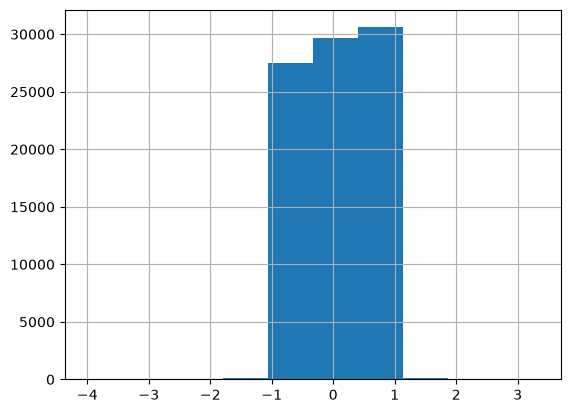

In [8]:
df['custom_002'].hist()


### Correlation Matrix

In [9]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()

,Open,High,Low,Close,Volume,hour,minute,day_of_month,month,year,...,remain_session_net_move,long_mae,short_mae,long_mfe,short_mfe,rr_long,rr_short,eod_return_long,eod_return_short,price_range
Open,1.000000,0.999986,0.999985,0.999978,0.118442,-0.000122,0.000135,0.002431,0.028570,0.674605,...,-0.017519,0.017074,-0.001400,-0.001400,0.017074,0.015192,0.019695,-0.005231,0.005231,0.321295
High,0.999986,1.000000,0.999974,0.999987,0.120290,0.000495,-0.000071,0.002451,0.028552,0.674713,...,-0.017358,0.017684,-0.000500,-0.000500,0.017684,0.015166,0.019630,-0.005083,0.005083,0.323046
Low,0.999985,0.999974,1.000000,0.999988,0.116483,-0.000753,0.000356,0.002376,0.028605,0.674544,...,-0.017411,0.016184,-0.002205,-0.002205,0.016184,0.015233,0.019736,-0.005155,0.005155,0.319447
Close,0.999978,0.999987,0.999988,1.000000,0.118374,-0.000121,0.000145,0.002409,0.028563,0.674621,...,-0.017303,0.016853,-0.001320,-0.001320,0.016853,0.015216,0.019690,-0.005047,0.005047,0.321231
Volume,0.118442,0.120290,0.116483,0.118374,1.000000,0.253419,-0.025609,0.022163,0.005070,0.214890,...,0.007385,0.108414,0.131220,0.131220,0.108414,-0.010332,-0.020666,0.005367,-0.005367,0.313135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rr_long,0.015192,0.015166,0.015233,0.015216,-0.010332,-0.031529,-0.004765,-0.023449,-0.003515,0.029754,...,0.278173,-0.145721,0.278462,0.278462,-0.145721,1.000000,-0.044153,0.243649,-0.243649,0.080069
rr_short,0.019695,0.019630,0.019736,0.019690,-0.020666,-0.035701,0.001007,0.000551,-0.005777,0.001273,...,-0.280215,0.278179,-0.136445,-0.136445,0.278179,-0.044153,1.000000,-0.248095,0.248095,0.097720
eod_return_long,-0.005231,-0.005083,-0.005155,-0.005047,0.005367,0.001849,-0.002626,-0.014335,0.004310,0.023782,...,0.871359,-0.698435,0.673953,0.673953,-0.698435,0.243649,-0.248095,1.000000,-1.000000,-0.042143
eod_return_short,0.005231,0.005083,0.005155,0.005047,-0.005367,-0.001849,0.002626,0.014335,-0.004310,-0.023782,...,-0.871359,0.698435,-0.673953,-0.673953,0.698435,-0.243649,0.248095,-1.000000,1.000000,0.042143


### Redundancy

In [10]:
corr_matrix = df.select_dtypes(include='number').corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
redundancy = [col for col in upper.columns if any(upper[col] > 0.9)]

In [11]:
redundancy

['High',
 'Low',
 'Close',
 'time_int',
 'bar_in_day',
 'session_progress',
 'prev_day_close',
 'prev_day_open',
 'prev_day_high',
 'prev_day_low',
 'prev_day_pivot',
 'prev_trading_day_high',
 'prev_trading_day_low',
 'prev_trading_day_close',
 'prev_day_r1',
 'prev_day_s1',
 'first_close_0915',
 'pre_1345_high',
 'pre_1355_low',
 'prev_day_1445_close',
 'morning_high',
 'morning_low',
 'morning_mid',
 'range_sma20',
 'candle_range_ratio',
 'ibs',
 'heikin_ashi_close',
 'heikin_ashi_open',
 'fractal_high',
 'fractal_low',
 'fractal_high_ffill',
 'fractal_low_ffill',
 'sma20',
 'sma50',
 'close_min_10',
 'close_max_10',
 'ema_fast',
 'ema_slow',
 'tsi',
 'macd_line',
 'ppo_line',
 'cmo',
 'mb',
 'std',
 'ub',
 'lb',
 'cci',
 'kdj_d',
 'kdj_j',
 'kama',
 'rbias',
 'mtm',
 'demarker',
 'williams_r',
 'slow_stoch_d',
 'coppock',
 'dpo',
 'pfe',
 'high_ma_bias',
 'bollinger_width',
 'bollinger_percent_b',
 'rsi_mean',
 'osc',
 'short_quiet_momentum',
 'rsi_v2',
 'cmo_v2',
 'bias_v13',
 're